## STEP 1 : Formulate Research Question

Research Question :  "How accurately can food delivery time  be predicted using distance and preparation time, and how strongly does each factor influence delivery duration?"

## Identification of Variables ##

Dependent Variables (y) : Delivery_Time_min (The target value we want to predict)

Independent Variables (X): Distance_km, Preparation_Time_min (The input features we use to predict the target value)


## Objective

To build a multiple linear regression model that predicts food delivery time  using the independent variables 
distance and preparation time. The aim is to evaluate how these two core factors influence delivery 
duration and to assess the model’s accuracy in forecasting delivery times.

## Step 2 : Data Validation and Cleaning

In [2]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("Food_Delivery_Times.csv")

# View dataset
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [3]:
# Dataset structure
df.shape
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    str    
 3   Traffic_Level           970 non-null    str    
 4   Time_of_Day             970 non-null    str    
 5   Vehicle_Type            1000 non-null   str    
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 70.4 KB


,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
count,1000.000000,1000.000000,1000.000000,970.000000,1000.000000
mean,500.500000,10.059970,16.982000,4.579381,56.732000
std,288.819436,5.696656,7.204553,2.914394,22.070915
min,1.000000,0.590000,5.000000,0.000000,8.000000
25%,250.750000,5.105000,11.000000,2.000000,41.000000
50%,500.500000,10.190000,17.000000,5.000000,55.500000
75%,750.250000,15.017500,23.000000,7.000000,71.000000
max,1000.000000,19.990000,29.000000,9.000000,153.000000


In [4]:
# Check missing values
df.isnull().sum()

# Check duplicates
df.duplicated().sum()

np.int64(0)

In [5]:
# Remove irrelevant column if exists
if 'Order_ID' in df.columns:
    df = df.drop(columns=['Order_ID'])

# Drop missing values
df = df.dropna()

## Data Cleaning Summary
The dataset was checked for missing values, duplicates, and irrelevant columns. Order_ID was removed and missing values were handled to ensure clean data for modeling.

##  Step 3 : Explanatory Data Analalysis

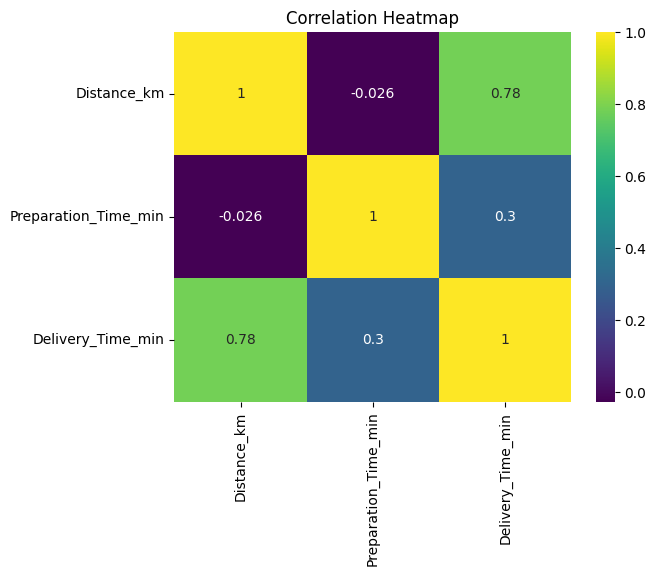

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
sns.heatmap(df[['Distance_km', 'Preparation_Time_min', 'Delivery_Time_min']].corr(),
            annot=True, cmap="viridis")
plt.title("Correlation Heatmap")
plt.show()

The distribution shows how delivery times are spread across the dataset and helps identify skewness or normal distribution.

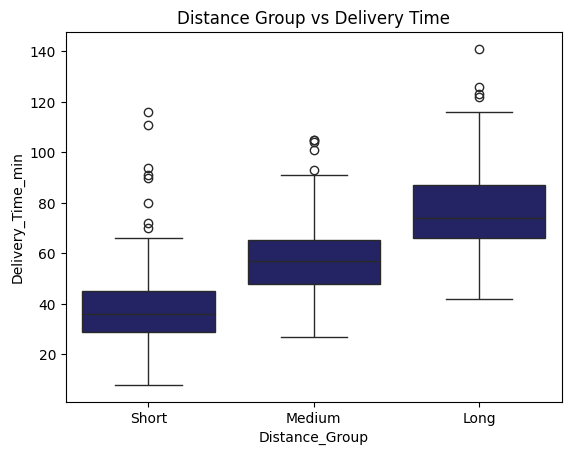

In [28]:
df['Distance_Group'] = pd.cut(df['Distance_km'], bins=3, labels=['Short', 'Medium', 'Long'])

plt.figure()
sns.boxplot(x=df['Distance_Group'], y=df['Delivery_Time_min'], color="midnightblue")
plt.title("Distance Group vs Delivery Time")
plt.show()

Delivery time increases as distance group increases, showing a clear relationship between distance and delivery time.

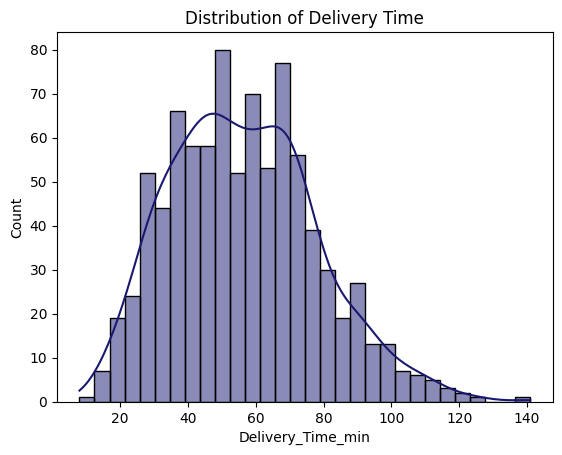

In [25]:
plt.figure()
sns.histplot(df['Delivery_Time_min'], bins=30, kde=True, color="midnightblue")
plt.title("Distribution of Delivery Time")
plt.show()

The heatmap shows strong positive correlations between the independent variables and delivery time, confirming their suitability for regression.

## Step 4: Model Training

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [10]:
# Define variables
X = df[['Distance_km', 'Preparation_Time_min']]
y = df['Delivery_Time_min']

In [11]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [12]:
# Train model
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [13]:
# Coefficients
coefficients = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])
coefficients

,Coefficient
Distance_km,2.979753
Preparation_Time_min,0.885217


In [14]:
# Intercept
model.intercept_

np.float64(11.84477019170064)

## Step 5: Performance Evaluation

In [15]:
from sklearn import metrics

In [16]:
# Predictions
y_pred = model.predict(X_test)

In [17]:
# Evaluation metrics
print("MAE:", metrics.mean_absolute_error(y_test, y_pred))
print("MSE:", metrics.mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
print("R2 Score:", metrics.r2_score(y_test, y_pred))

MAE: 7.23437945192863
MSE: 99.25510762286872
RMSE: 9.962685763531274
R2 Score: 0.7651460993105067


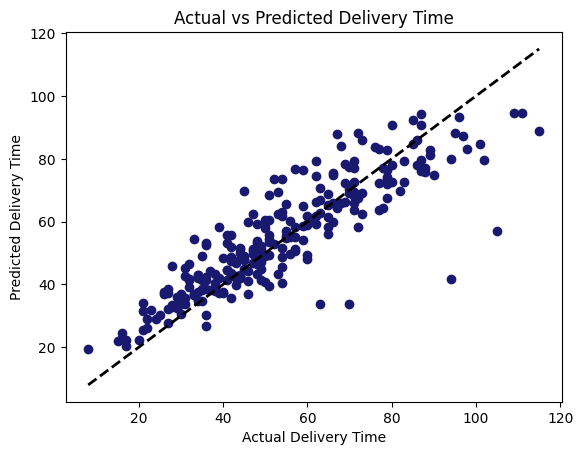

In [ ]:
import pickle

plt.figure()
plt.scatter(y_test, y_pred, color='midnightblue')
plt.xlabel("Actual Delivery Time")
plt.ylabel("Predicted Delivery Time")
plt.title("Actual vs Predicted Delivery Time")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2 )
plt.show()


with open("ITC_106L_PREFINAL_TUGAS.pkl", "wb") as f:
    pickle.dump(model, f)

The closer the points are to the diagonal line, the better the model performance. R² score indicates how well the model explains the data.

## Step 6: Reflection and Analysis
## 1. Do the variables significantly affect delivery time?
- Yes. Distance and preparation time both have strong effects on delivery time since longer travel distance and longer preparation lead to increased delivery duration.

## 2. Identify limitation of the model and dataset:
- The model has limitation for the reason that it does not consider real-life factors such as traffic conditions, weather changesor possible delays from the rider.

## 3. Which variable contributes most to delivery?
- Distance_km contributes more compared to preparation_time for the reason that it directly affects travel time and shows stronger influence in both EDA and coefficients.

## 4. If strongest predictor is removed:
- Removing the strongest predictor will reduce the model's effectiveness, leading to lower accuracy and higher prediction error since an important factor is missing.

## 5. Does correlation imply causation?
- No. Correlation only shows relationship, not direct causation. For instance, distance is related to delivery time. but it does not really entirely cause delays without considering the other elements like traffic condition etc.